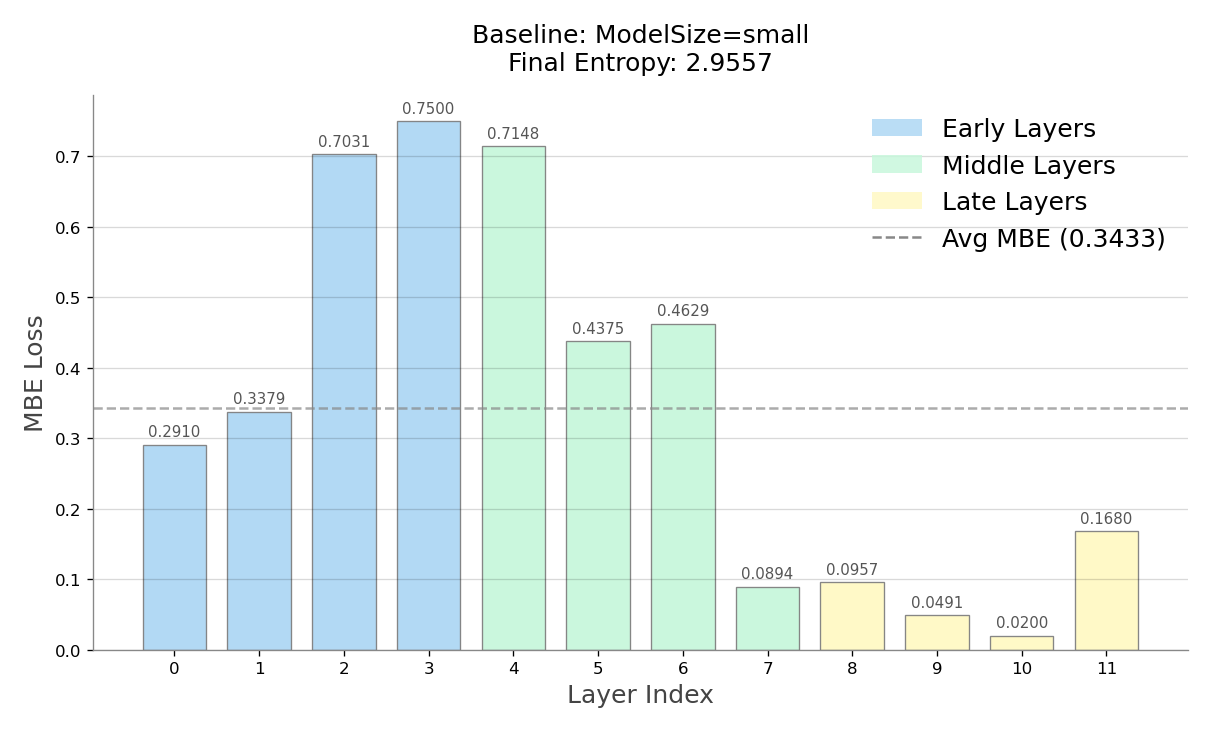

In [6]:
# Analysis on log runs 
from src.utils import *

# ----- IBLM ----- 
log_path = "logs/fineweb10B-gpt2-small-20k.txt"
# log_path = "logs/iblm-fineweb10B-gpt2-small-20k.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])

# --- visualize dynamics ---
frames = []
for i in range(len(loss_record["entropy"])):
    if i % 1 == 0: # Optional: skip frames for speed
        print(f"Rendering frame {i}/{len(loss_record['entropy'])}", end='\r')
        frames.append(create_training_frame(i, loss_record, run_info=run_info, n_layer=n_layer))

frames[0].save(
    f"mbe_dynamics_{run_info}.gif",
    save_all=True,
    append_images=frames[1:],
    duration=100, # ms per frame
    loop=0
)

# --- visualize final losses ---
visualize_final_losses(loss_record, run_info=run_info, n_layer=n_layer)

In [27]:
# Question #1. Are there learning efficiency benefits from IBLM? 
# From the iblm small runs, we don't observe much benefits
import numpy as np 

log_path1 = "logs/fineweb10B-gpt2-medium-20k.txt"
log_path2 = "logs/iblm-fineweb10B-gpt2-medium-20k.txt"

# --- extract log data ---
_, loss_record1 = extract_log_data(log_path1)
_, loss_record2 = extract_log_data(log_path2)

gpt_entropy = np.array(loss_record1["entropy"])
iblm_entropy = np.array(loss_record2["entropy"])

((gpt_entropy - iblm_entropy) / gpt_entropy) * 100

array([0.        , 0.30914923, 0.59755318, 0.21426403, 0.2388572 ,
       0.23098309, 0.03805849, 0.19113645, 0.20670923, 0.10700911,
       0.18127975, 0.12680398, 0.28689946, 0.25392613, 0.18046695,
       0.12040057, 0.11256308, 0.11759855, 0.1869481 , 0.10775643,
       0.13735365, 0.14371287, 0.14893344, 0.14190439, 0.11220067,
       0.09892524, 0.15576895, 0.17565233, 0.15953242, 0.1691796 ,
       0.14835327, 0.09543617, 0.15252286, 0.14755863, 0.13769876,
       0.12890726, 0.14070003, 0.09625504, 0.08673756, 0.08327996,
       0.06725905, 0.09923797, 0.11813017, 0.12433508, 0.11450083,
       0.09230532, 0.06329047, 0.06287769, 0.07759596, 0.0724746 ,
       0.08055342, 0.05647765, 0.09030063, 0.06809186, 0.06638085,
       0.06411931, 0.08268807, 0.09122473, 0.04613556, 0.03911205,
       0.04494787, 0.06205497, 0.07070876, 0.05246332, 0.07682146,
       0.03605723, 0.03269402, 0.0575059 , 0.073464  , 0.09053302,
       0.03755418, 0.03554808, 0.04251511, 0.07826174, 0.08330

In [25]:
gpt_entropy[:30], iblm_entropy[:30]

(array([10.82584953,  4.36565828,  3.96441841,  3.7771709 ,  3.65697217,
         3.57715988,  3.55512118,  3.41069388,  3.36781478,  3.33445668,
         3.30850959,  3.28379321,  3.2553463 ,  3.22137117,  3.20292449,
         3.1865561 ,  3.17268491,  3.16050434,  3.14481068,  3.12702441,
         3.11576247,  3.10596585,  3.09938598,  3.09044099,  3.07732368,
         3.06997061,  3.0610292 ,  3.05236888,  3.04680371,  3.041049  ]),
 array([10.82584953,  4.35216188,  3.9407289 ,  3.76907778,  3.64823723,
         3.56889725,  3.55376816,  3.4041748 ,  3.3608532 ,  3.33088851,
         3.30251193,  3.27962923,  3.24600673,  3.21319127,  3.19714427,
         3.18271947,  3.16911364,  3.15678763,  3.13893151,  3.12365484,
         3.11148286,  3.10150218,  3.09476995,  3.08605552,  3.0738709 ,
         3.06693363,  3.05626106,  3.04700732,  3.04194307,  3.03590417]))

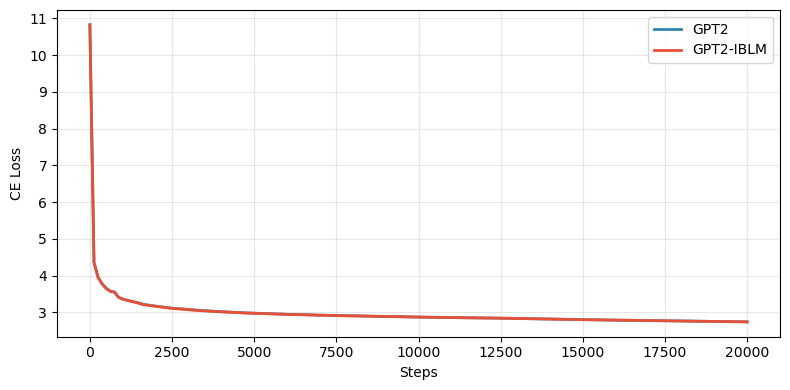

In [22]:
def plot_entropy_comparison(entropy_1, entropy_2, labels=('GPT2', 'GPT2-IBLM'), val_interval=125):
    steps_1 = np.arange(len(entropy_1)) * val_interval
    steps_2 = np.arange(len(entropy_2)) * val_interval
    
    plt.figure(figsize=(8, 4))
    plt.plot(steps_1, entropy_1, label=labels[0], color='#2E86AB', linewidth=2)
    plt.plot(steps_2, entropy_2, label=labels[1], color='#E94F37', linewidth=2)
    plt.xlabel('Steps')
    plt.ylabel('CE Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

# Usage:
plot_entropy_comparison(gpt_entropy, iblm_entropy)

In [5]:
len(loss_record["entropy"])

65

In [2]:
{k: loss_record[k][-1]for k in loss_record}

{'mbe_0': 0.88671875,
 'mbe_1': 0.7265625,
 'mbe_2': 0.546875,
 'mbe_3': 0.09375,
 'mbe_4': 0.061279296875,
 'mbe_5': 0.033447265625,
 'mbe_6': 0.03857421875,
 'mbe_7': 0.05419921875,
 'mbe_8': 0.06591796875,
 'mbe_9': 0.10693359375,
 'mbe_10': 0.30859375,
 'mbe_11': 0.85546875,
 'mbe_12': 0.9453125,
 'mbe_13': 0.7890625,
 'mbe_14': 0.5078125,
 'mbe_15': 0.0908203125,
 'mbe_16': 0.224609375,
 'mbe_17': 1.0390625,
 'mbe_18': 1.1640625,
 'mbe_19': 1.125,
 'mbe_20': 1.328125,
 'mbe_21': 1.421875,
 'mbe_22': 1.3046875,
 'mbe_23': 0.9921875,
 'mbe_24': 1.015625,
 'mbe_25': 0.74609375,
 'mbe_26': 0.7578125,
 'mbe_27': 0.76953125,
 'mbe_28': 0.7265625,
 'mbe_29': 0.65625,
 'mbe_30': 0.55078125,
 'mbe_31': 0.5703125,
 'mbe_32': 0.0927734375,
 'mbe_33': 0.1015625,
 'mbe_34': 0.09130859375,
 'mbe_35': 0.0966796875,
 'mbe_36': 0.099609375,
 'mbe_37': 0.10009765625,
 'mbe_38': 0.09814453125,
 'mbe_39': 0.0966796875,
 'mbe_40': 0.072265625,
 'mbe_41': 0.06982421875,
 'mbe_42': 0.07421875,
 'mbe_43'

In [19]:
# --- Total hours required to pre-train on 10B tokens ---
tok_per_batch = (32 * 16 * 1024)
total_tok = 10 * 10**9
num_epoch = 1
steps = (num_epoch * total_tok) / tok_per_batch
ms_per_step = 5619 
total_hours = steps * ms_per_step / 1000 / 60 / 60

total_hours

29.770533243815105

In [42]:
# Issue #1. Rotation adopting 'skip_last=1' -> last few layer MBE very low
#           this is not ideal, we want mid-layer to be compressed more


In [1]:
from sorl.stat import extract_log_data

# ----- SoRL ----- 
log_path = "logs/sorl-21.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])
if "attn sweep" not in run_info:
    run_info += " + attn_sweep" 

# --- visualize dynamics --- 
# (1). x-axis: step, y-axis: search info gain, util rate, search adv, cond_traj_loss, base_traj_loss 
#     group some of them together (cond_traj_loss, base_traj_loss) (search info gain, search adv), util rate
#     3 rows 1 column, make a gif plot out

{k: loss_record[k][-1]for k in loss_record}

{'base_traj_loss': 1.0347,
 'cond_traj_loss (greedy)': 1.0509,
 'abs_loss (greedy)': 0.7554,
 'greedy_adv': 0.0984,
 'info_gain (greedy)': -0.0125,
 'util_rate': 0.4675,
 'K': 8.0}

In [2]:
from sorl.stat import generate_sorl_dynamics_gif

generate_sorl_dynamics_gif(loss_record, "logs/k_curriculum_dynamics.gif", run_info, val_interval=125, fps=5)

ValueError: min() iterable argument is empty